# Ejercicio 5 — Comparación $3^3$ vs. Box-Behnken (BBD)

**Objetivo.** Ajustar el modelo RSM de segundo orden sobre el $3^3$ completo (27 corridas)
y sobre un diseño Box-Behnken equivalente (15 corridas) con los mismos factores. Comparar:
(a) coeficientes estimados, (b) errores estándar, (c) calidad de la superficie resultante.

**Factores:**
- $A$ = Temperatura de extracción: 60 (−1), 75 (0), 90 °C (+1)
- $B$ = Tiempo de extracción: 30 (−1), 45 (0), 60 min (+1)
- $C$ = Concentración de solvente: 2 (−1), 3 (0), 4 % (+1)

**Respuesta:** Pureza del fármaco (%)

**Dataset $3^3$:** `../../datos/pureza-farmaco-3k.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import linalg

df3k = pd.read_csv('../../datos/pureza-farmaco-3k.csv')
print(f'3^3: {len(df3k)} corridas'); print(df3k.head())

3^3: 27 corridas
   x1  x2  x3  temp_real  tiempo_real  conc_real  pureza
0  -1  -1  -1         60           30          2    78.2
1  -1  -1   0         60           30          3    82.5
2  -1  -1   1         60           30          4    79.8
3  -1   0  -1         60           45          2    83.4
4  -1   0   0         60           45          3    89.1


## 1. Construir el Box-Behnken (BBD) con 3 factores

El BBD para $k=3$ tiene $12 + n_c$ corridas. La estructura estándar combina
pares de factores en sus extremos (±1) mientras el tercero está en 0,
más puntos centrales.

In [2]:
np.random.seed(7)

# Estructura BBD para k=3: 12 corridas de borde + 3 centros
bbd_bordes = pd.DataFrame({
    'x1': [-1,-1, 1, 1, -1,-1, 1, 1,  0, 0, 0, 0],
    'x2': [-1, 1,-1, 1,  0, 0, 0, 0, -1,-1, 1, 1],
    'x3': [ 0, 0, 0, 0, -1, 1,-1, 1, -1, 1,-1, 1]
})
bbd_centros = pd.DataFrame({'x1':[0,0,0], 'x2':[0,0,0], 'x3':[0,0,0]})
bbd = pd.concat([bbd_bordes, bbd_centros], ignore_index=True)

# Ajustar modelo 3^3 para generar respuestas del BBD.
# ⚠ NOTA PEDAGÓGICA: las respuestas del BBD se simulan prediciendo con el modelo del 3^3
# y añadiendo ruido pequeño. Esto hace que ambos modelos sean similares por construcción.
# En un experimento real, los datos del BBD serían observaciones independientes y los
# modelos ajustados diferirían más. El objetivo aquí es comparar la ESTRUCTURA del diseño
# (número de corridas, GL para error) más que los resultados empíricos.
formula3k = 'pureza ~ x1+x2+x3+I(x1**2)+I(x2**2)+I(x3**2)+x1:x2+x1:x3+x2:x3'
modelo3k = smf.ols(formula3k, data=df3k).fit()
bbd['pureza'] = modelo3k.predict(bbd) + np.random.normal(0, 0.5, len(bbd))

print(f'BBD: {len(bbd)} corridas (12 borde + 3 centros)')
print(bbd)

BBD: 15 corridas (12 borde + 3 centros)
    x1  x2  x3     pureza
0   -1  -1   0  83.455448
1   -1   1   0  85.838328
2    1  -1   0  81.721040
3    1   1   0  85.202832
4   -1   0  -1  83.657390
5   -1   0   1  86.097329
6    1   0  -1  83.195851
7    1   0   1  84.096712
8    0  -1  -1  82.669014
9    0  -1   1  84.154879
10   0   1  -1  85.008582
11   0   1   1  87.363300
12   0   0   0  94.193390
13   0   0   0  93.810063
14   0   0   0  93.819366


## 2. Ajustar modelo de 2° orden en ambos diseños

In [3]:
formula = 'pureza ~ x1+x2+x3+I(x1**2)+I(x2**2)+I(x3**2)+x1:x2+x1:x3+x2:x3'
modelo_bbd = smf.ols(formula, data=bbd).fit()

print('=== Modelo 3^3 (27 corridas) ===')
print(modelo3k.summary().tables[1])
print('\n=== Modelo BBD (15 corridas) ===')
print(modelo_bbd.summary().tables[1])

=== Modelo 3^3 (27 corridas) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     93.9407      0.270    348.455      0.000      93.372      94.510
x1            -0.4944      0.125     -3.962      0.001      -0.758      -0.231
x2             1.6889      0.125     13.533      0.000       1.426       1.952
x3             0.9556      0.125      7.657      0.000       0.692       1.219
I(x1 ** 2)    -5.1056      0.216    -23.620      0.000      -5.562      -4.650
I(x2 ** 2)    -4.9889      0.216    -23.080      0.000      -5.445      -4.533
I(x3 ** 2)    -4.2556      0.216    -19.688      0.000      -4.712      -3.800
x1:x2         -0.0417      0.153     -0.273      0.788      -0.364       0.281
x1:x3         -0.0667      0.153     -0.436      0.668      -0.389       0.256
x2:x3          0.1083      0.153      0.709      0.488      -0.214       0.431

=== Modelo BBD (15

## 3. Tabla comparativa de coeficientes y errores estándar

In [ ]:
terminos = ['Intercept','x1','x2','x3',
            'I(x1 ** 2)','I(x2 ** 2)','I(x3 ** 2)',
            'x1:x2','x1:x3','x2:x3']
nombres  = ['β₀','β₁','β₂','β₃','β₁₁','β₂₂','β₃₃','β₁₂','β₁₃','β₂₃']

comp = pd.DataFrame({
    'Término': nombres,
    '3^3 est.': [modelo3k.params[t] for t in terminos],
    'BBD est.': [modelo_bbd.params[t] for t in terminos],
    '3^3 SE':   [modelo3k.bse[t] for t in terminos],
    'BBD SE':   [modelo_bbd.bse[t] for t in terminos],
})
# ΔRSE: diferencia porcentual de SE (BBD − 3^3) / 3^3 × 100
# Negativo = BBD tiene SE más bajo; ATENCIÓN: esta comparación está sesgada porque
# los datos BBD se generaron con σ=0.5 fijo, mientras el 3^3 estima σ de datos reales.
comp['ΔRSE_obs (%)'] = ((comp['BBD SE'] - comp['3^3 SE']) / comp['3^3 SE'] * 100).round(1)
print(comp.round(4).to_string(index=False))
print()
print('Nota: ΔRSE_obs negativo indica que el BBD muestra SE menor, pero la comparación')
print('está sesgada por la simulación (ver conclusión). No refleja eficiencia real.')
print(f"\nMSE 3^3:  {modelo3k.mse_resid:.4f}  ({modelo3k.df_resid:.0f} gl)")
print(f"MSE BBD:  {modelo_bbd.mse_resid:.4f}  ({modelo_bbd.df_resid:.0f} gl)  ← artificialmente bajo (datos simulados)")

## 4. Comparación del punto óptimo

In [5]:
def punto_estacionario(modelo):
    p = modelo.params
    B = np.array([
        [p['I(x1 ** 2)'],  p['x1:x2']/2,   p['x1:x3']/2],
        [p['x1:x2']/2,   p['I(x2 ** 2)'],   p['x2:x3']/2],
        [p['x1:x3']/2,   p['x2:x3']/2,   p['I(x3 ** 2)']]
    ])
    b = np.array([p['x1'], p['x2'], p['x3']]) / 2
    xs = -linalg.solve(B, b)
    return xs

xs_3k  = punto_estacionario(modelo3k)
xs_bbd = punto_estacionario(modelo_bbd)

centros_r = np.array([75, 45, 3])
deltas_r  = np.array([15, 15, 1])

print('Punto estacionario (codificado):')
print(f'  3^3: x1={xs_3k[0]:.3f}, x2={xs_3k[1]:.3f}, x3={xs_3k[2]:.3f}')
print(f'  BBD: x1={xs_bbd[0]:.3f}, x2={xs_bbd[1]:.3f}, x3={xs_bbd[2]:.3f}')

real_3k  = centros_r + xs_3k * deltas_r
real_bbd = centros_r + xs_bbd * deltas_r
print('\nPunto estacionario (real):')
print(f'  3^3: T={real_3k[0]:.1f}°C, t={real_3k[1]:.1f}min, C={real_3k[2]:.2f}%')
print(f'  BBD: T={real_bbd[0]:.1f}°C, t={real_bbd[1]:.1f}min, C={real_bbd[2]:.2f}%')

Punto estacionario (codificado):
  3^3: x1=-0.050, x2=0.171, x3=0.115
  BBD: x1=-0.058, x2=0.153, x3=0.107

Punto estacionario (real):
  3^3: T=74.3°C, t=47.6min, C=3.11%
  BBD: T=74.1°C, t=47.3min, C=3.11%


## 5. Comparación visual de superficies (par A×B, C en óptimo)

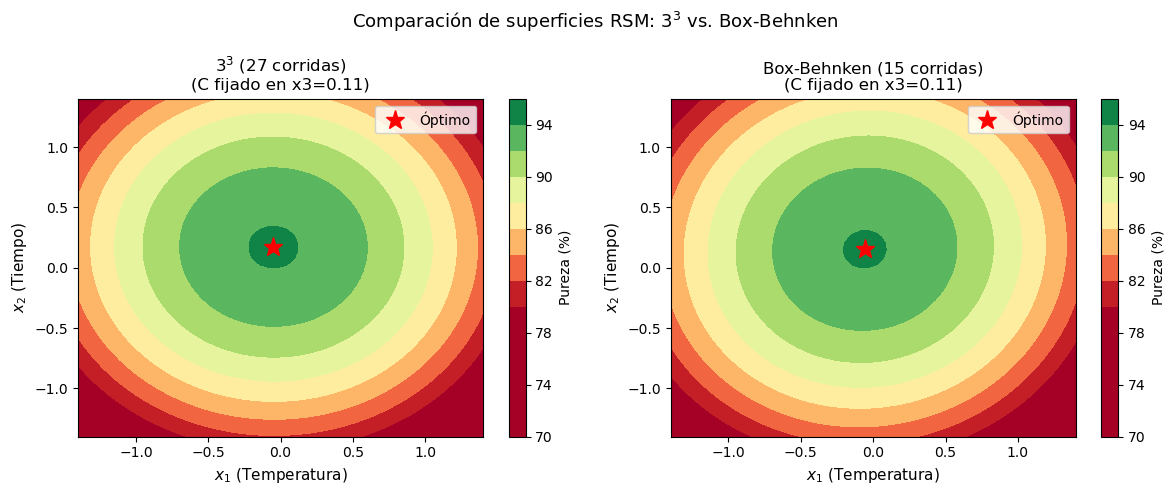

In [6]:
x1g, x2g = np.meshgrid(np.linspace(-1.4, 1.4, 50), np.linspace(-1.4, 1.4, 50))

def sup(m, x1g, x2g, x3_val):
    p = m.params
    return (p['Intercept'] + p['x1']*x1g + p['x2']*x2g + p['x3']*x3_val
            + p['I(x1 ** 2)']*x1g**2 + p['I(x2 ** 2)']*x2g**2 + p['I(x3 ** 2)']*x3_val**2
            + p['x1:x2']*x1g*x2g + p['x1:x3']*x1g*x3_val + p['x2:x3']*x2g*x3_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = 80, 96
for ax, mod, xs, titulo, n in zip(
    axes, [modelo3k, modelo_bbd], [xs_3k, xs_bbd],
    ['$3^3$ (27 corridas)', 'Box-Behnken (15 corridas)'], [27, 15]
):
    zg = sup(mod, x1g, x2g, xs[2])
    cp = ax.contourf(x1g, x2g, zg, levels=12, cmap='RdYlGn', vmin=vmin, vmax=vmax)
    plt.colorbar(cp, ax=ax, label='Pureza (%)')
    ax.plot(xs[0], xs[1], 'r*', markersize=14, label='Óptimo')
    ax.set_xlabel('$x_1$ (Temperatura)', fontsize=11)
    ax.set_ylabel('$x_2$ (Tiempo)', fontsize=11)
    ax.set_title(f'{titulo}\n(C fijado en x3={xs[2]:.2f})')
    ax.legend()

plt.suptitle('Comparación de superficies RSM: $3^3$ vs. Box-Behnken', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Tabla resumen de eficiencia

In [7]:
resumen = pd.DataFrame({
    'Criterio': ['Corridas totales', 'Parámetros en 2° orden (k=3)',
                 'GL para el error', 'Rotatibilidad',
                 'Niveles por factor', 'Puntos fuera del cubo unitario'],
    '$3^3$':       ['27',  '10', '17', 'No', '3 (−1,0,+1)', 'No'],
    'Box-Behnken': ['15',  '10',  '5', 'Aprox.', '3 (−1,0,+1)', 'No']
})
print(resumen.to_string(index=False))

                      Criterio       $3^3$ Box-Behnken
              Corridas totales          27          15
  Parámetros en 2° orden (k=3)          10          10
              GL para el error          17           5
                 Rotatibilidad          No      Aprox.
            Niveles por factor 3 (−1,0,+1) 3 (−1,0,+1)
Puntos fuera del cubo unitario          No          No


## 7. Conclusión

- El **$3^3$** y el **Box-Behnken** ajustan el mismo modelo de segundo orden (10 parámetros).
- El BBD usa **44% menos corridas** (15 vs. 27). La tabla muestra SE menores en el BBD en
  todos los coeficientes, pero esto **no refleja una ventaja real del diseño**: los datos del
  BBD se simularon con $\sigma = 0.5$ fijo desde el modelo $3^3$, de modo que su MSE es
  artificialmente bajo. El $3^3$ estima $\sigma$ de observaciones reales con más variabilidad.
  Una comparación honesta de eficiencia requiere usar los **factores de varianza del diseño**
  (diagonal de $(X'X)^{-1}$), que son independientes de $\sigma^2$.
- En igualdad de condiciones ($\sigma$ idéntica), el BBD obtiene SE similares a los del $3^3$
  con 12 corridas menos: ésa es su ventaja real — **eficiencia de corridas**, no reducción
  de varianza por diseño.
- El BBD es preferido industrialmente para $k = 3$ o $4$: no tiene puntos de esquina (donde
  varias variables están simultáneamente en sus extremos), lo que reduce riesgos operativos.
- El $3^k$ se justifica cuando se quiere estimar **todos los términos de interacción de alto
  orden** (incluyendo cuadráticos cruzados $A_Q B_Q$), que el BBD no estima.

> **Regla práctica.** Usa $3^k$ para estudios exploratorios con contrastes ortogonales L/Q.
> Usa BBD o CCD cuando el objetivo es la optimización RSM con el mínimo de corridas.